In [20]:
import geopandas as gpd
import xarray
import matplotlib.pyplot as plt
import rasterio
import xrspatial
import xvec
import pandas as pd
from shapely.ops import nearest_points
import contextily as ctx

#### get the data

In [21]:
fp = "./data/raw/jordan-260316-free/gis_osm_pois_free_1.shp"
cafes = gpd.read_file(fp)
cafes = cafes[cafes["fclass"] == "cafe"]
cafes = cafes[["name", "geometry"]].reset_index(drop=True)
print(cafes.shape)
cafes.head(3)

(408, 2)


,name,geometry
0,None,POINT (35.44723 30.32025)
1,ستاربكس,POINT (35.88988 31.94214)
2,None,POINT (35.75192 32.33275)


In [22]:
fp = "./data/raw/jordan-260316-free/gis_osm_pois_a_free_1.shp"
parks = gpd.read_file(fp)
parks = parks[parks["fclass"] == "park"]
parks = parks[["name", "geometry"]].reset_index(drop=True)
print(parks.shape)
parks.head(3)

(369, 2)


,name,geometry
0,None,"POLYGON ((35.00064 29.52771, 35.00097 29.52783..."
1,Princess Salma Park,"POLYGON ((35.00389 29.52689, 35.00411 29.52739..."
2,Prince Haya Park,"POLYGON ((35.00117 29.53485, 35.00265 29.53485..."


In [23]:
fp = "./data/raw/jordan-260316-free/gis_osm_roads_free_1.shp"
roads = gpd.read_file(fp)
roads = roads[roads['fclass'].isin(['motorway','trunk','primary','secondary','tertiary'])]
roads = roads[["name", "geometry"]].reset_index(drop=True)
print(roads.shape)
roads.head(3)

(13971, 2)


,name,geometry
0,הערבה,"LINESTRING (35.15478 30.39421, 35.15389 30.396..."
1,None,"LINESTRING (36.17153 32.09005, 36.17188 32.089..."
2,شارع الكرك,"LINESTRING (35.87528 31.21866, 35.87709 31.218..."


(2, 2)


,NAME_2,geometry
0,Amman,"MULTIPOLYGON (((36.00878 31.91764, 36.0075 31...."
1,Wadi Essier,"MULTIPOLYGON (((35.97852 31.97042, 35.96665 31..."


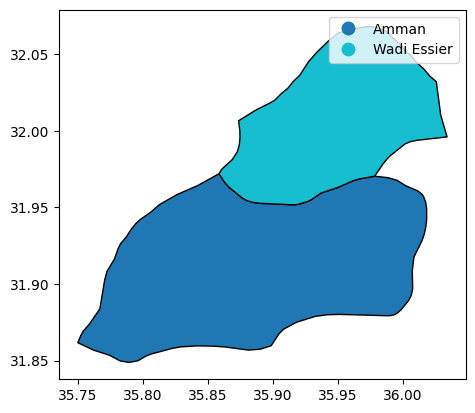

In [24]:
fp = "./data/raw/gadm41_JOR.gpkg"
aoi = ["Amman", "Wadi Essier"]
boundaries = gpd.read_file(fp, layer='ADM_ADM_2')
boundaries = boundaries[boundaries["NAME_1"] == "Amman"]
boundaries = boundaries[boundaries['NAME_2'].isin(aoi)]
boundaries = boundaries[["NAME_2", "geometry"]].reset_index(drop=True)
print(boundaries.shape)
display(boundaries)
boundaries.plot(column="NAME_2", legend=True, edgecolor="black");

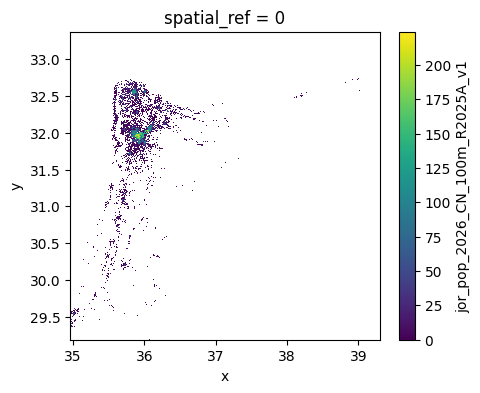

In [25]:
fp = "./data/raw/jor_pop_2026_CN_100m_R2025A_v1.tif"
pop = xarray.open_dataset(fp, engine="rasterio", masked=True)
pop = pop.squeeze("band", drop=True)
pop = pop.rename({"band_data": "population"})
pop["population"].plot(figsize=(5,4));

In [26]:
print(cafes.crs)
print(parks.crs)
print(roads.crs)
print(boundaries.crs)
print(pop.rio.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


#### reprojection to UoM: meters

In [27]:
target_crs = "EPSG:32636"
cafes = cafes.to_crs(target_crs)
parks = parks.to_crs(target_crs)
roads = roads.to_crs(target_crs)
boundaries = boundaries.to_crs(target_crs)
pop = pop.rio.reproject(dst_crs=target_crs)

print(cafes.crs)
print(parks.crs)
print(roads.crs)
print(boundaries.crs)
print(pop.rio.crs)

EPSG:32636
EPSG:32636
EPSG:32636
EPSG:32636
EPSG:32636


#### clipping to aoi defined in boundaries

In [28]:
cafes_clip = gpd.clip(cafes, boundaries)
parks_clip = gpd.clip(parks, boundaries)
roads_clip = gpd.clip(roads, boundaries)
pop_clip = pop.rio.clip(geometries=boundaries.geometry, crs=pop["population"].rio.crs)

In [29]:
print(f"statistics of {aoi}")
print(f"number of cafes: {cafes_clip.shape[0]}")
print(f"number of parks: {parks_clip.shape[0]}")
print(f"population: {pop_clip["population"].sum().item():,}")

statistics of ['Amman', 'Wadi Essier']
number of cafes: 140
number of parks: 77
population: 3,335,907.75


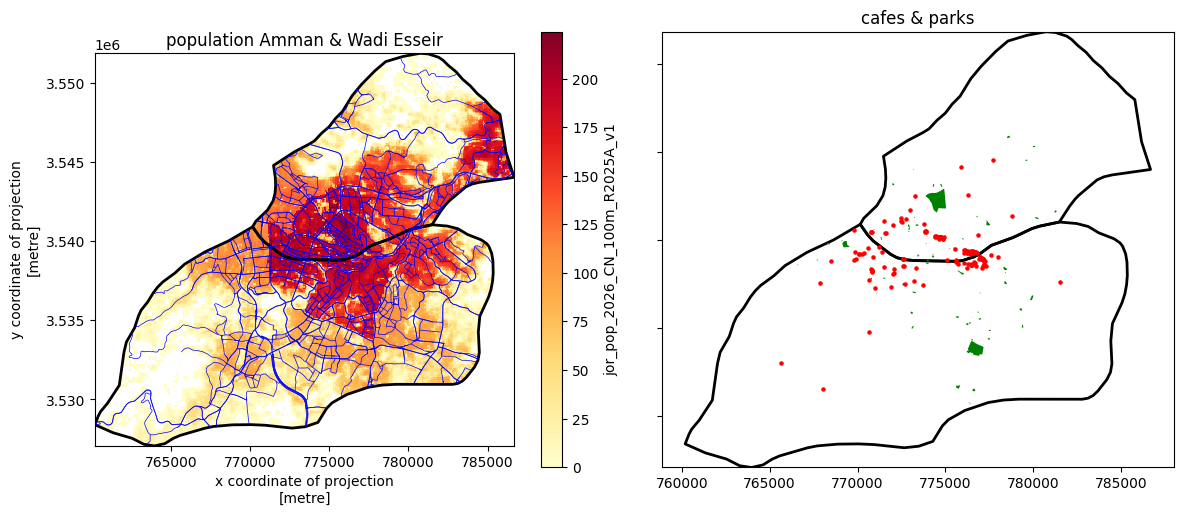

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), sharey=True)

pop_clip["population"].plot(ax=ax1, cmap="YlOrRd", add_colorbar=True)
roads_clip.plot(ax=ax1, edgecolor="blue", linewidth=0.5)
boundaries.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=2)
ax1.set_title("population Amman & Wadi Esseir");

#roads_clip.plot(ax=ax2, edgecolor="blue", linewidth=0.5)
boundaries.plot(ax=ax2, facecolor="none", edgecolor="black", linewidth=2)
parks_clip.plot(ax=ax2, facecolor="green")
cafes_clip.plot(ax=ax2, color="red", markersize=5)
ax2.set_title("cafes & parks")
plt.tight_layout();

#### extract population density for park buffers

In [31]:
# 500 m buffer
buffer_meters = 400
parks_buffer = parks_clip.copy()
parks_buffer['geometry'] = parks_buffer.geometry.buffer(buffer_meters)
parks_buffer = parks_buffer.reset_index(drop=True)

stats = pop_clip["population"].xvec.zonal_stats(
    geometry=parks_buffer.geometry,
    x_coords="x",
    y_coords="y",
    stats=["sum", "mean"],
    all_touched=True,
)
print(stats.zonal_statistics.values)

stats_df = pd.DataFrame(stats, columns=["pop_sum", "pop_mean"])
parks_buffer = pd.concat([parks_buffer, stats_df], axis=1)
parks_buffer.head(3)

['sum' 'mean']


,name,geometry,pop_sum,pop_mean
0,parc abdallat,"POLYGON ((771042.026 3537395.196, 771075.015 3...",2464.886475,46.507294
1,Mahal,"POLYGON ((770613.156 3537504.289, 770652.248 3...",6540.127441,83.847786
2,Deir Ghbar Park,"POLYGON ((770365.135 3537835.596, 770365.957 3...",9299.141602,109.401665


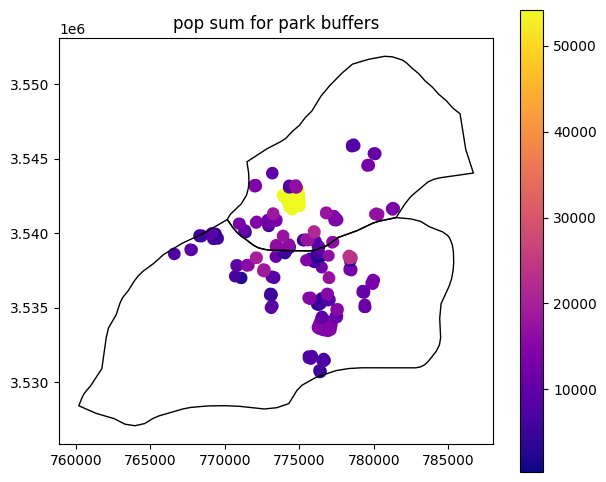

In [32]:
fig, ax= plt.subplots(1, 1, figsize=(7,6), sharey=True)
parks_buffer.plot(ax=ax, column="pop_sum", cmap="plasma", legend=True)
boundaries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.set_title("pop sum for park buffers");

#### find nearest cafe and road from park centroids

In [33]:
parks_buffer['centroid'] = parks_buffer.geometry.centroid
parks_buffer = parks_buffer.set_geometry("centroid")

parks_buffer = gpd.sjoin_nearest(
    parks_buffer, roads_clip,
    how="left",
    distance_col="dist_to_road"
)
parks_buffer = parks_buffer.rename(columns={
    "index_right": "closest_road_indx",
    "name_right": "closesst_road_name" 
})

parks_buffer = gpd.sjoin_nearest(
    parks_buffer, cafes_clip,
    how="left",
    distance_col="dist_to_cafe"
)
parks_buffer = parks_buffer.rename(columns={
    "index_right": "closest_cafe_indx",
    "name": "closest_cafe_name" 
})

parks_buffer = parks_buffer.set_geometry("geometry")

parks_buffer.head(3)

,name_left,geometry,pop_sum,pop_mean,centroid,closest_road_indx,closesst_road_name,dist_to_road,closest_cafe_indx,closest_cafe_name,dist_to_cafe
0,parc abdallat,"POLYGON ((771042.026 3537395.196, 771075.015 3...",2464.886475,46.507294,POINT (771083.474 3536985.681),8943,None,240.456568,138,منزل فابريزيا,293.189833
1,Mahal,"POLYGON ((770613.156 3537504.289, 770652.248 3...",6540.127441,83.847786,POINT (770680.52 3537098.238),4158,شارع هاشم السقاف,60.278096,138,منزل فابريزيا,353.804140
2,Deir Ghbar Park,"POLYGON ((770365.135 3537835.596, 770365.957 3...",9299.141602,109.401665,POINT (770796.314 3537816.956),3301,شارع الهاشميين,106.528766,349,the best cafe,174.291537


In [34]:
parks_buffer[['dist_to_road', 'dist_to_cafe']].describe()

,dist_to_road,dist_to_cafe
count,80.000000,80.000000
mean,137.995905,1452.890164
std,115.020461,1632.346563
min,2.597249,30.334073
25%,42.738652,388.652420
50%,96.369321,814.084898
75%,208.394898,1856.263918
max,435.875073,7081.902099


#### normalize and score

In [35]:
parks_buffer['pop_score'] = parks_buffer['pop_sum'] / parks_buffer['pop_sum'].max()  # higher is better
parks_buffer['road_score'] = 1 - (parks_buffer['dist_to_road'] / parks_buffer['dist_to_road'].max())  # closer to road = higher
parks_buffer['cafe_score'] = parks_buffer['dist_to_cafe'] / parks_buffer['dist_to_cafe'].max()  # farther from cafe = higher

parks_buffer['total_score'] = (
    0.50 * parks_buffer['pop_score'] +
    0.20 * parks_buffer['road_score'] +
    0.30 * parks_buffer['cafe_score']
)

#### results

In [36]:
best_locations = parks_buffer.sort_values(by='total_score', ascending=False)
print("top 10 candidates:")
best_locations[['name_left', 'total_score','pop_sum','dist_to_road','dist_to_cafe']].head(10)

top 10 candidates:


,name_left,total_score,pop_sum,dist_to_road,dist_to_cafe
70,حديقة المدينة الرياضية,0.572508,54154.234375,398.743198,1309.437752
19,Abu Baker Community Park,0.470241,7188.193848,169.362036,6647.185993
18,حديقة,0.444941,5317.668457,217.552235,6979.603224
21,حديقة الصخرة المشرفة,0.440279,9839.849609,52.374801,4094.783914
28,حديقة حطين للطيور,0.430616,14991.306641,130.212366,3586.993922
65,حديقة المأمونية,0.415233,21675.160156,24.554176,622.632382
63,حديقة الطيور ماركا,0.410917,13574.946289,45.924572,2517.691271
27,حدبقة الامانة الروضة,0.410558,10645.523438,129.797156,4056.191029
72,حديقه مروريه الساحه الهاشميه,0.404209,16735.695312,34.727744,1549.161987
20,منتزه يعقوب السلطي,0.391886,7660.700195,287.634636,5975.621174


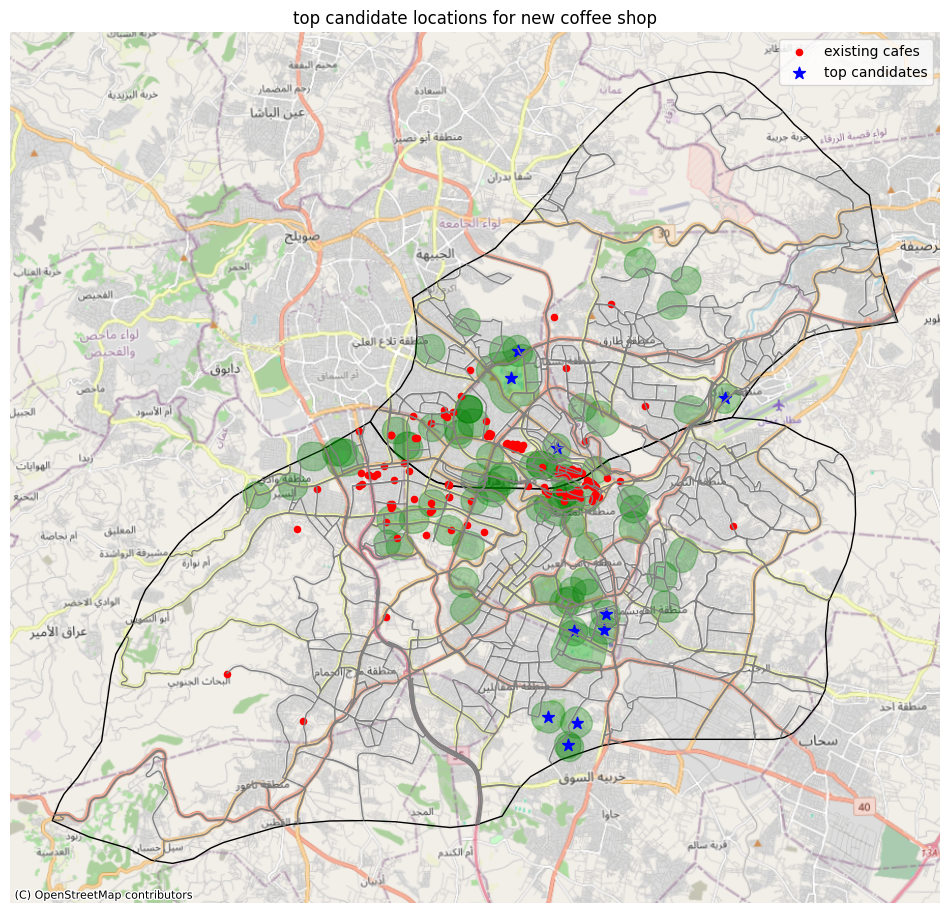

In [37]:
top_candidates = best_locations.head(10)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
boundaries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
parks_buffer.plot(ax=ax, color="green", alpha=0.3, edgecolor="green")
roads_clip.plot(ax=ax, color="gray", linewidth=1)
cafes_clip.plot(ax=ax, color="red", markersize=20, label="existing cafes")

top_candidates = top_candidates.set_geometry("centroid")
top_candidates.plot(ax=ax, color="blue", markersize=80, label="top candidates", marker="*")

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=top_candidates.crs.to_string())

plt.legend()
plt.title("top candidate locations for new coffee shop")
plt.axis("off");